# Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!pip install torch_geometric

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.6 MB/s eta 0:00:00


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor
import joblib


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.nn import GCNConv, GAE
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


class ShallowEncoder(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ShallowEncoder, self).__init__()
        # Single Graph Convolutional Layer
        self.conv1 = GCNConv(in_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        return x


class ExpressionMLP(nn.Module):
    def __init__(self, input_dim=32, hidden_dim=64, output_dim=1):
        super(ExpressionMLP, self).__init__()

        # Define the fully connected layers
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2), # Helps prevent overfitting
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, output_dim) # No activation for regression
        )

    def forward(self, x):
        return self.network(x)


def train_gae(model, optimizer, x, edge_index, epochs=200):
    """
    Trains a Graph Autoencoder to reconstruct network edges.
    Returns the trained model and a list of epoch losses.
    """
    model.train()
    loss_history = []

    for epoch in range(epochs):
        optimizer.zero_grad()

        # Encode the node features and graph structure into latent embedding 'z'
        z = model.encode(x, edge_index)

        # Calculate reconstruction loss (how well 'z' can recreate the iGRN edges)
        loss = model.recon_loss(z, edge_index)

        # Backpropagate and update weights
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'Epoch: {epoch + 1:03d} | GAE Recon Loss: {loss.item():.4f}')

    return model, loss_history


def train_mlp(model, inputs, targets, epochs=300, lr=0.001):
    """
    Trains a Multi-Layer Perceptron (MLP) to predict expression values.
    Returns the trained model and a list of epoch losses.
    """
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=0.01)
    criterion = nn.MSELoss() # Standard regression loss

    model.train()
    loss_history = []

    for epoch in range(epochs):
        optimizer.zero_grad()

        # Forward pass
        predictions = model(inputs)

        # Calculate loss against the ground truth expression values
        loss = criterion(predictions, targets)

        # Backpropagation
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(f'MLP Epoch: {epoch + 1:03d} | MSE Loss: {loss.item():.4f}')

    return model, loss_history


def get_mlp_results(mlp_model, Y_train_genes, Y_test_genes, X_train_genes,
                    X_test_genes, scaler, train_exps, all_experiments):
    # 1. Set the model to evaluation mode
    mlp_model.eval()

    # 2. Generate predictions for BOTH splits
    with torch.no_grad():
        train_predictions = mlp_model(X_train_genes).cpu().numpy()
        test_predictions = mlp_model(X_test_genes).cpu().numpy()

    # 3. Move targets to CPU
    train_targets = Y_train_genes.cpu().numpy()
    test_targets = Y_test_genes.cpu().numpy()

    # --- UNSCALING LOGIC ---
    # 4. Identify indices of the specific experiments used as targets
    train_exp_indices = [all_experiments.index(exp) for exp in train_exps]

    # 5. Extract means and stds for those experiments from the scaler
    exp_means = scaler.mean_[train_exp_indices]
    exp_stds = scaler.scale_[train_exp_indices]

    # 6. Step A: Reverse the StandardScaler (Z-score -> Log-TPM)
    train_predictions_log = (train_predictions * exp_stds) + exp_means
    train_targets_log = (train_targets * exp_stds) + exp_means

    test_predictions_log = (test_predictions * exp_stds) + exp_means
    test_targets_log = (test_targets * exp_stds) + exp_means

    # 7. Step B: Reverse the Log-transformation (Log-TPM -> Raw TPM)
    # np.expm1 calculates exp(x) - 1, which perfectly reverses np.log1p
    train_predictions_tpm = np.expm1(train_predictions_log)
    train_targets_tpm = np.expm1(train_targets_log)

    test_predictions_tpm = np.expm1(test_predictions_log)
    test_targets_tpm = np.expm1(test_targets_log)

    # --- METRIC CALCULATION (Scaled/Log space) ---
    # Note: These metrics are calculated on the Z-scores (the model's direct output)
    train_mse = mean_squared_error(train_targets, train_predictions)
    test_mse = mean_squared_error(test_targets, test_predictions)
    train_rho, _ = spearmanr(train_targets.flatten(), train_predictions.flatten())
    test_rho, _ = spearmanr(test_targets.flatten(), test_predictions.flatten())

    # --- METRIC CALCULATION (Real Units: Raw TPM) ---
    train_mae_tpm = mean_absolute_error(train_targets_tpm, train_predictions_tpm)
    test_mae_tpm = mean_absolute_error(test_targets_tpm, test_predictions_tpm)

    train_mse_tpm = mean_squared_error(train_targets_tpm, train_predictions_tpm)
    test_mse_tpm = mean_squared_error(test_targets_tpm, test_predictions_tpm)

    # 8. Construct the Results DataFrame
    results_df = pd.DataFrame({
        'Metric': ['MSE (Scaled)', 'MAE (TPM)', 'MSE (TPM)', 'Spearman Correlation'],
        'Train (Seen Genes)': [train_mse, train_mae_tpm, train_mse_tpm, train_rho],
        'Test (Unseen Genes)': [test_mse, test_mae_tpm, test_mse_tpm, test_rho]
    })

    return (results_df, (train_predictions_tpm, train_targets_tpm,
                         test_predictions_tpm, test_targets_tpm))


def plot_expression_predictions(targets_tpm, predictions_tpm, sample_size=None,
                                title=None):
    # 1. Flatten and Log-transform the entire dataset first
    actual_log_all = np.log1p(targets_tpm.flatten())
    pred_log_all = np.log1p(predictions_tpm.flatten())

    # 2. Calculate Spearman on the FULL dataset for accuracy
    overall_rho, _ = spearmanr(actual_log_all, pred_log_all)

    # 3. Take a random sample for the visual plot
    if sample_size is None:
        actual_plot = actual_log_all
        pred_plot = pred_log_all
    elif len(actual_log_all) > sample_size:
        # Set a seed for reproducibility
        np.random.seed(42)
        indices = np.random.choice(len(actual_log_all), sample_size,
                                   replace=False)
        actual_plot = actual_log_all[indices]
        pred_plot = pred_log_all[indices]
    else:
        actual_plot = actual_log_all
        pred_plot = pred_log_all

    pearson_r = pd.DataFrame({
        'Actual': actual_log_all,
        'Predicted': pred_log_all
    }).corr().iloc[0, 1]

    # 4. Create the plot
    plt.figure(figsize=(8, 8))

    # Plot the sample
    plt.scatter(actual_plot, pred_plot, alpha=0.5, s=15, color='teal',
                edgecolor='white', linewidth=0.5,
                label=f'n={len(actual_plot)}')

    # Identity Line (Perfect Prediction)
    max_val = max(actual_log_all.max(), pred_log_all.max())
    plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', lw=2,
             label='Perfect Prediction')

    # Add Overall Metric to the plot
    plt.text(0.05, 0.92, f'Spearman ρ: {overall_rho:.3f}',
             transform=plt.gca().transAxes, fontsize=12,
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
    plt.text(0.05, 0.87, f'Pearson r: {pearson_r:.3f}',
             transform=plt.gca().transAxes, fontsize=12,
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

    plt.xlabel("Actual Expression [log(TPM + 1)]")
    plt.ylabel("Predicted Expression [log(TPM + 1)]")
    if title is not None:
        plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.15)

    plt.tight_layout()
    plt.show()

## Load data

In [3]:
# Define paths and file names
# For Colab use
# root_path = 'drive/MyDrive/ECE542/'
# For local use
root_path = '/content/'
data_path = root_path
tf_filenames_dict = {
    'maize'     : 'Zma_TF_list.txt',
    'rice'      : 'Osj_TF_list.txt',
    'sorghum'   : 'Sbi_TF_list.txt'
}

Load expression data

In [4]:
# Load and format expression data
exp_data = pd.read_csv("/content/zma_osa_sbi_ortho_hai_expr_all.tsv", sep='\t')
exp_data.columns = [col.lower().replace('.','_') for col in exp_data.columns]
exp_data.head()

,gene_id,mean_leaf_section_1,mean_leaf_section_2,mean_leaf_section_3,mean_leaf_section_4,mean_leaf_section_6,mean_leaf_section_7,mean_leaf_section_8,mean_leaf_section_9,mean_leaf_section_10,...,srr6257228_mean,srr6257231_mean,srr8401514_mean,srr9202997_mean,srr9202998_mean,srr9203000_mean,srr9203001_mean,srr9203002_mean,srr9203003_mean,srr9203005_mean
0,ORTHO04M000001,4.546497,6.520382,6.253503,6.826752,6.745223,3.363057,5.000000,4.141401,4.249045,...,2.605618,1.835184,1.601559,2.432007,1.622150,2.686271,1.748511,2.181920,2.756412,2.326934
1,ORTHO04M000002,5.568790,10.509554,11.924204,7.954140,3.438217,0.000000,1.582803,1.537580,1.446497,...,10.177549,3.879458,0.796495,6.654203,1.350818,4.058331,6.377811,3.781891,2.106601,6.723717
2,ORTHO04M000003,5.755689,4.791018,4.871257,5.071257,4.532335,0.161677,3.382036,2.816168,3.359880,...,28.256274,29.906009,3.003803,9.677179,7.787140,10.327200,13.166616,9.940935,9.422623,13.480669
3,ORTHO04M000004,5.931737,7.356886,9.832934,9.923952,6.170659,0.000000,3.388623,2.559281,2.589820,...,5.598559,7.510683,2.290947,3.690457,2.634284,4.460366,4.990626,3.275099,3.170542,5.966543
4,ORTHO04M000005,22.267045,31.086364,33.167045,26.302273,12.117045,2.005682,7.471591,6.215909,5.164773,...,8.677945,10.664965,1.042287,10.677949,1.715857,7.845614,13.432008,10.941222,4.615420,18.174727


Load TF data

In [5]:
# Load TF data from PlantDB
tf_data_dict = {}
all_tf_gene_ids = []
for crop, filename in tf_filenames_dict.items():
    # Load and format data
    temp_df = pd.read_csv(f'{data_path}{filename}', sep='\t')
    temp_df.columns = [col.lower().replace('.','_') for col in temp_df.columns]

    # Add data to dictionary and gene IDs to list
    tf_data_dict[crop] = temp_df
    all_tf_gene_ids += tf_data_dict[crop]['gene_id'].tolist()

# Get a set of unique TF gene IDs
all_tf_gene_ids = set(all_tf_gene_ids)
print(len(all_tf_gene_ids))

6010


Load mapping data

In [6]:
# Load and format ortholog mapping data
map_data = pd.read_csv('/content/orthos_maize_outward.tsv', sep='\t')
map_data.columns = [col.lower().replace('#','') for col in map_data.columns]
map_data['og'] = map_data.og.apply(lambda x: f"ORTHO04M{x[2:].zfill(6)}")

# Get orthologous gene IDs
tf_ortho_ids = (
    map_data.query('orthologous_gene in @all_tf_gene_ids')
    ['og'].unique().tolist()
)
print(len(tf_ortho_ids))

1591


## Random Forest

Train RF model

In [ ]:
# # Memory-Optimized Initialization
# rf_model = RandomForestRegressor(
#     n_estimators=100,
#     random_state=42,
#     n_jobs=-1,
#     # Reduces feature evaluation from 558 to ~24 per split
#     max_features='sqrt',
#     # Each tree uses 70% of rows, saving RAM during sorting
#     max_samples=0.7,
#     # Prevents trees from growing deep enough to exhaust memory
#     max_depth=20,
#     # Stops splits early if they don't have enough data
#     min_samples_leaf=5,
#     # Required for max_samples to work
#     bootstrap=True
# )

# print("Training Optimized Random Forest Regressor...")
# rf_model.fit(X_train, Y_train)
# print('Done!')

Save/load RF model

In [6]:
!pip install joblib

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
import warnings

def plot_expression_predictions(targets_tpm, predictions_tpm, sample_size=None, title=None):
    # Ensure inputs are numpy arrays
    Y_true = np.asarray(targets_tpm)
    Y_pred = np.asarray(predictions_tpm)

    # 1. Flatten and Log-transform for the visual scatter plot
    actual_log_all = np.log1p(Y_true.flatten())
    pred_log_all = np.log1p(Y_pred.flatten())

    # 2. CORRECTED: Calculate Mean GENE-WISE Correlation
    gene_spearman = []
    gene_pearson = []

    # Assuming rows are samples and columns are genes
    with warnings.catch_warnings():
        warnings.simplefilter("ignore") # Ignores warnings from genes with zero variance (constant expressions)
        for i in range(Y_true.shape[1]):
            # Gene-wise Spearman (Rank based, so raw TPM is fine)
            s_corr, _ = spearmanr(Y_true[:, i], Y_pred[:, i])
            if not np.isnan(s_corr):
                gene_spearman.append(s_corr)

            # Gene-wise Pearson (Linear based, so it's best to compute on log1p transformed data)
            p_corr, _ = pearsonr(np.log1p(Y_true[:, i]), np.log1p(Y_pred[:, i]))
            if not np.isnan(p_corr):
                gene_pearson.append(p_corr)

    # Calculate the unbiased average of gene performances
    overall_rho = np.mean(gene_spearman)
    overall_pearson = np.mean(gene_pearson)

    # 3. Take a random sample for the visual plot
    if sample_size is None:
        actual_plot = actual_log_all
        pred_plot = pred_log_all
    elif len(actual_log_all) > sample_size:
        # Set a seed for reproducibility
        np.random.seed(42)
        indices = np.random.choice(len(actual_log_all), sample_size, replace=False)
        actual_plot = actual_log_all[indices]
        pred_plot = pred_log_all[indices]
    else:
        actual_plot = actual_log_all
        pred_plot = pred_log_all

    # 4. Create the plot
    plt.figure(figsize=(8, 8))

    # Plot the sample
    plt.scatter(actual_plot, pred_plot, alpha=0.5, s=15, color='teal',
                edgecolor='white', linewidth=0.5,
                label=f'n={len(actual_plot)}')

    # Identity Line (Perfect Prediction)
    max_val = max(actual_log_all.max(), pred_log_all.max())
    plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', lw=2,
             label='Perfect Prediction')

    # Add Corrected Metrics to the plot
    plt.text(0.05, 0.92, f'Mean Gene-Wise Spearman ρ: {overall_rho:.3f}',
             transform=plt.gca().transAxes, fontsize=12,
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
    plt.text(0.05, 0.87, f'Mean Gene-Wise Pearson r: {overall_pearson:.3f}',
             transform=plt.gca().transAxes, fontsize=12,
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

    plt.xlabel("Actual Expression [log(TPM + 1)]")
    plt.ylabel("Predicted Expression [log(TPM + 1)]")

    if title is not None:
        plt.title(title)

    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.15)

    plt.tight_layout()
    plt.show()

In [8]:
import joblib
model_filename = f'/content/drive/MyDrive/rf_model_noGAE.joblib'

# Save model
# print(f"Saving model to {model_filename}...")
# joblib.dump(rf_model, model_filename)
# print("Model saved successfully!")

# Load model
rf_model = joblib.load(model_filename)

In [9]:
X_all = (
    exp_data.query('gene_id in @tf_ortho_ids')
    .set_index('gene_id').T.copy().fillna(0)
)
Y_all = (
    exp_data.query('gene_id not in @tf_ortho_ids')
    .set_index('gene_id').T.copy().fillna(0)
)

# Implement the 80:20 Train-Test Split across experiments
X_train, X_test, Y_train, Y_test = train_test_split(X_all, Y_all,
                                                    test_size=0.20,
                                                    random_state=42)

In [10]:
# Ensure Y is a numpy array for consistent operations with Y_pred
Y_pred = rf_model.predict(X_all)
Y_true = Y_all.to_numpy()

# Initialize a list to store Spearman correlation coefficients for each target gene
spearman_correlations = []

# Iterate through each target gene (column) to calculate correlation
# Y_pred and Y_true have shape (n_samples, n_features)
for i in range(Y_true.shape[1]):
    # Calculate Spearman correlation for the i-th target gene
    # between its actual values and predicted values across all samples
    corr, _ = spearmanr(Y_true[:, i], Y_pred[:, i])
    spearman_correlations.append(corr)

# Convert the list of correlations to a pandas Series for easier analysis
spearman_series = pd.Series(spearman_correlations, index=Y_all.columns)

# Display descriptive statistics of the correlations
print("Descriptive Statistics of Spearman Correlations for Target Genes:")
display(spearman_series.describe())

# Optionally, display the first few correlations
print("\nTop 10 Spearman Correlations:")
display(spearman_series.nlargest(10))

print("\nBottom 10 Spearman Correlations (can indicate negative correlation or poor prediction):")
display(spearman_series.nsmallest(10))

mean_rho = np.nanmean(spearman_series)
print(f"Mean Spearman Correlation: {mean_rho:.2f}")

/tmp/ipykernel_14868/1210771720.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(Y_true[:, i], Y_pred[:, i])


Descriptive Statistics of Spearman Correlations for Target Genes:


,0
count,17723.000000
mean,0.614500
std,0.293056
min,-0.108895
25%,0.333767
50%,0.749741
75%,0.870069
max,0.964583



Top 10 Spearman Correlations:


,0
gene_id,
ORTHO04M000995,0.964583
ORTHO04M001365,0.959385
ORTHO04M003474,0.958542
ORTHO04M002784,0.957670
ORTHO04M001476,0.957378
ORTHO04M001656,0.957161
ORTHO04M000404,0.956123
ORTHO04M003472,0.955194
ORTHO04M000658,0.954992



Bottom 10 Spearman Correlations (can indicate negative correlation or poor prediction):


,0
gene_id,
ORTHO04M011611,-0.108895
ORTHO04M008117,-0.073203
ORTHO04M002033,-0.056511
Zm00001d000567,-0.020976
ORTHO04M008603,-0.014154
ORTHO04M005981,-0.006425
ORTHO04M206076,0.011694
ORTHO04M205905,0.013255
Zm00001d052571,0.013949


Mean Spearman Correlation: 0.61


Overall Model Metrics across all Target Genes:


,Spearman_Rho,R2_Score,MSE,MAE
count,17723.000000,17893.000000,1.789300e+04,17893.000000
mean,0.614500,0.440853,2.277648e+04,8.769131
std,0.293056,0.239810,5.598977e+05,40.423823
min,-0.108895,-0.004317,1.201742e-05,0.000143
25%,0.333767,0.211800,1.693347e-01,0.100778
50%,0.749741,0.455377,1.879548e+01,2.128633
75%,0.870069,0.655901,1.630653e+02,6.477994
max,0.964583,0.959975,3.318013e+07,1715.442241


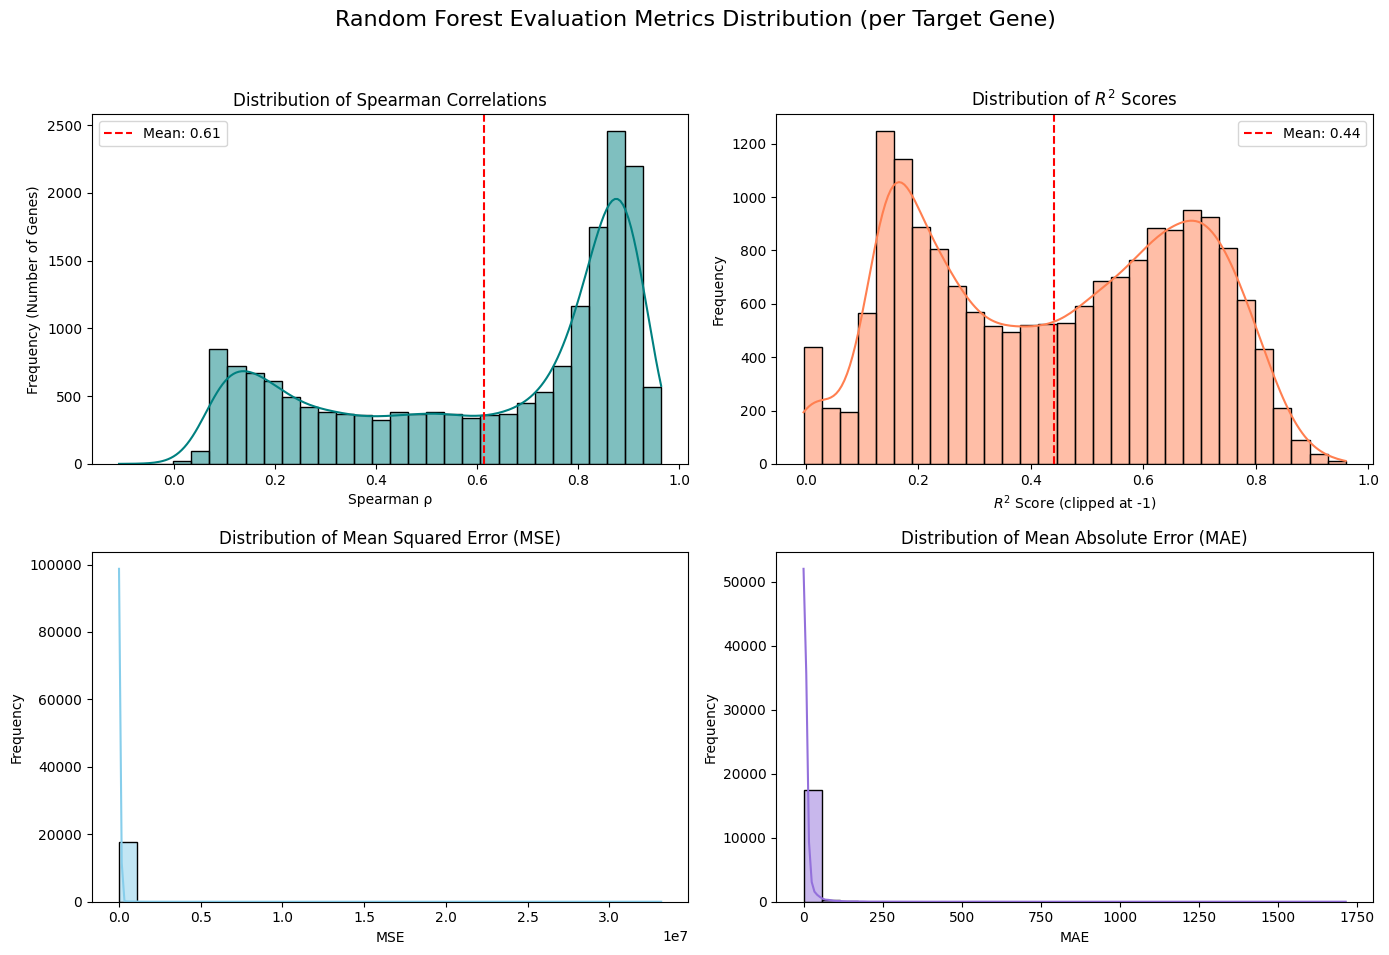

In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate other evaluation parameters for each target gene
r2_scores = []
mse_scores = []
mae_scores = []

# Iterate through each target gene to calculate standard regression metrics
for i in range(Y_true.shape[1]):
    # Note: spearman is already calculated in your code above
    r2 = r2_score(Y_true[:, i], Y_pred[:, i])
    mse = mean_squared_error(Y_true[:, i], Y_pred[:, i])
    mae = mean_absolute_error(Y_true[:, i], Y_pred[:, i])

    r2_scores.append(r2)
    mse_scores.append(mse)
    mae_scores.append(mae)

# Combine all metrics into a single pandas DataFrame for easy analysis
metrics_df = pd.DataFrame({
    'Spearman_Rho': spearman_series.values,
    'R2_Score': r2_scores,
    'MSE': mse_scores,
    'MAE': mae_scores
}, index=Y_all.columns)

print("Overall Model Metrics across all Target Genes:")
display(metrics_df.describe())

# 2. Plotting the evaluation parameters
# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Random Forest Evaluation Metrics Distribution (per Target Gene)', fontsize=16)

# Plot 1: Spearman Correlation distribution
sns.histplot(metrics_df['Spearman_Rho'], bins=30, ax=axes[0, 0], color='teal', kde=True)
axes[0, 0].set_title('Distribution of Spearman Correlations')
axes[0, 0].set_xlabel('Spearman ρ')
axes[0, 0].set_ylabel('Frequency (Number of Genes)')
axes[0, 0].axvline(metrics_df['Spearman_Rho'].mean(), color='red', linestyle='--',
                   label=f"Mean: {metrics_df['Spearman_Rho'].mean():.2f}")
axes[0, 0].legend()

# Plot 2: R2 Score distribution
# (Clipping R2 at 0 for visualization if some predictions are worse than baseline)
sns.histplot(metrics_df['R2_Score'].clip(lower=-1), bins=30, ax=axes[0, 1], color='coral', kde=True)
axes[0, 1].set_title('Distribution of $R^2$ Scores')
axes[0, 1].set_xlabel('$R^2$ Score (clipped at -1)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(metrics_df['R2_Score'].mean(), color='red', linestyle='--',
                   label=f"Mean: {metrics_df['R2_Score'].mean():.2f}")
axes[0, 1].legend()

# Plot 3: MSE distribution
sns.histplot(metrics_df['MSE'], bins=30, ax=axes[1, 0], color='skyblue', kde=True)
axes[1, 0].set_title('Distribution of Mean Squared Error (MSE)')
axes[1, 0].set_xlabel('MSE')
axes[1, 0].set_ylabel('Frequency')

# Plot 4: MAE distribution
sns.histplot(metrics_df['MAE'], bins=30, ax=axes[1, 1], color='mediumpurple', kde=True)
axes[1, 1].set_title('Distribution of Mean Absolute Error (MAE)')
axes[1, 1].set_xlabel('MAE')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

/tmp/ipykernel_14868/3466564611.py:21: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr_train, _ = spearmanr(Y_true_train[:, i], Y_pred_train[:, i])
/tmp/ipykernel_14868/3466564611.py:25: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr_test, _ = spearmanr(Y_true_test[:, i], Y_pred_test[:, i])


Descriptive Statistics: Train vs Test Spearman


,Train_Spearman,Test_Spearman
count,17723.000000,16568.000000
mean,0.623578,0.611720
std,0.290579,0.282275
min,-0.113974,-0.147875
25%,0.347011,0.372535
50%,0.761989,0.729360
75%,0.876591,0.849521
max,0.965898,0.959188


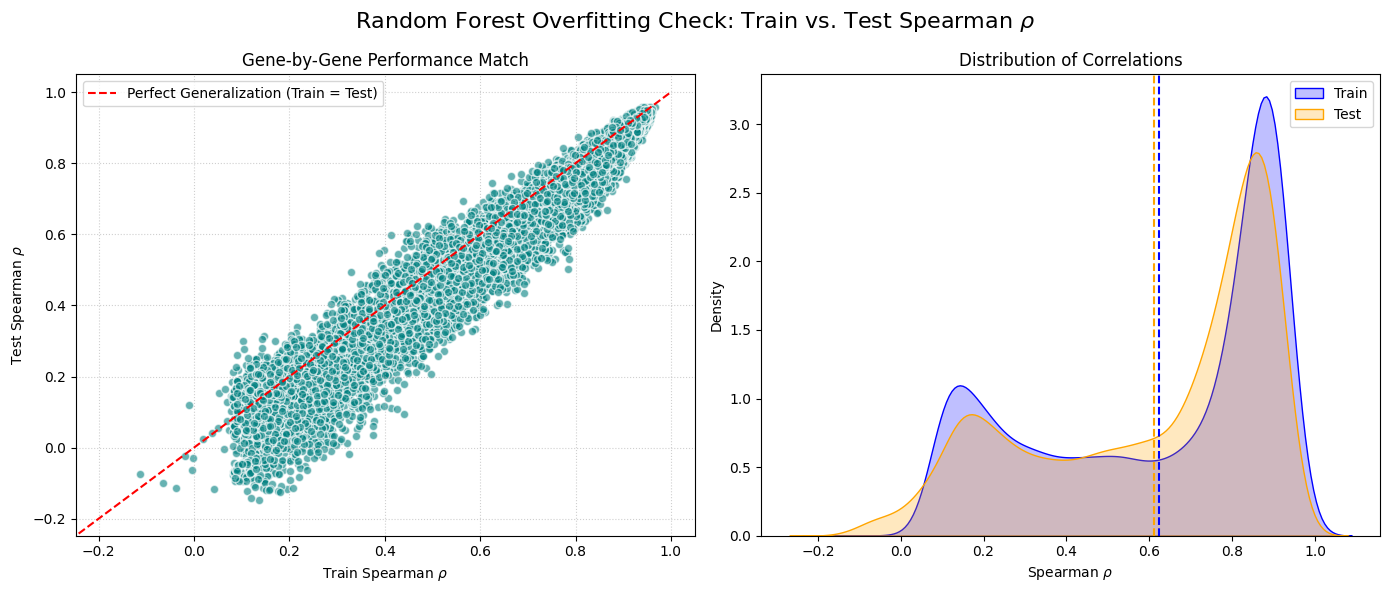

\nAverage drop in Spearman ρ from Train to Test: 0.0119
✅ Model seems to generalize well.


In [13]:
from scipy.stats import spearmanr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate predictions for BOTH Train and Test sets
Y_pred_train = rf_model.predict(X_train)
Y_pred_test = rf_model.predict(X_test)

# Convert actuals to numpy arrays for consistent slicing
Y_true_train = Y_train.to_numpy()
Y_true_test = Y_test.to_numpy()

# 2. Calculate Spearman correlation for each target gene
train_correlations = []
test_correlations = []

for i in range(Y_true_test.shape[1]):
    # Train Spearman for gene i
    corr_train, _ = spearmanr(Y_true_train[:, i], Y_pred_train[:, i])
    train_correlations.append(corr_train)

    # Test Spearman for gene i
    corr_test, _ = spearmanr(Y_true_test[:, i], Y_pred_test[:, i])
    test_correlations.append(corr_test)

# 3. Create a comparison DataFrame
compare_df = pd.DataFrame({
    'Train_Spearman': train_correlations,
    'Test_Spearman': test_correlations
}, index=Y_test.columns)

print("Descriptive Statistics: Train vs Test Spearman")
display(compare_df.describe())

# 4. Visualization: Scatter plot and Distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Random Forest Overfitting Check: Train vs. Test Spearman $\\rho$', fontsize=16)

# Plot A: Scatter plot of Train vs Test
axes[0].scatter(compare_df['Train_Spearman'], compare_df['Test_Spearman'],
                alpha=0.6, color='teal', edgecolor='white')
axes[0].plot([-1, 1], [-1, 1], color='red', linestyle='--', label='Perfect Generalization (Train = Test)')
axes[0].set_xlabel('Train Spearman $\\rho$')
axes[0].set_ylabel('Test Spearman $\\rho$')
axes[0].set_title('Gene-by-Gene Performance Match')
axes[0].set_xlim([min(0, compare_df.min().min() - 0.1), 1.05])
axes[0].set_ylim([min(0, compare_df.min().min() - 0.1), 1.05])
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

# Plot B: Overlapping Histograms
sns.kdeplot(compare_df['Train_Spearman'], ax=axes[1], color='blue', fill=True, label='Train')
sns.kdeplot(compare_df['Test_Spearman'], ax=axes[1], color='orange', fill=True, label='Test')
axes[1].axvline(compare_df['Train_Spearman'].mean(), color='blue', linestyle='--')
axes[1].axvline(compare_df['Test_Spearman'].mean(), color='orange', linestyle='--')
axes[1].set_xlabel('Spearman $\\rho$')
axes[1].set_ylabel('Density')
axes[1].set_title('Distribution of Correlations')
axes[1].legend()

plt.tight_layout()
plt.show()

# 5. Calculate Average Drop-off
avg_drop = compare_df['Train_Spearman'].mean() - compare_df['Test_Spearman'].mean()
print(f"\\nAverage drop in Spearman ρ from Train to Test: {avg_drop:.4f}")
if avg_drop > 0.15:
    print("⚠️ Warning: Significant drop detected. Your Random Forest model is likely overfitting. Consider reducing max_depth or increasing min_samples_leaf.")
else:
    print("✅ Model seems to generalize well.")